In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Inputs
csv_snog = "snog_5f.csv"
csv_simp = "simp_1e3sc10_raw_post.csv"
csv_lg_k3 = "LG_K3_50cuts2.csv"
csv_lg_k5 = "LG_K5_50cuts.csv"
csv_lg_k10 = "LG_K10_50cuts.csv"

# Y-axis range control for LB/UB plots (set to None to disable)
ymin, ymax = 0.975, 0.98

MIPGAP_STR = "1e-3"  # for title

def _norm(c: str) -> str:
    return "".join(ch for ch in str(c).lower() if ch.isalnum())

def pick_column(df, want_keys):
    for c in df.columns:
        n = _norm(c)
        if any(k in n for k in want_keys):
            s = pd.to_numeric(df[c], errors="coerce")
            if s.notna().mean() > 0.5:
                return c
    raise ValueError(f"Can't find column for {want_keys}. Columns={list(df.columns)}")

def load_one(fp: str, name: str):
    df = pd.read_csv(fp)
    time_col = pick_column(df, ["time", "times", "sec", "seconds"])
    lb_col   = pick_column(df, ["lb", "lowerbound", "dualbound", "zlb"])
    ub_col   = pick_column(df, ["ub", "upperbound", "primalbound", "zub"])
    return {"name": name, "df": df, "time_col": time_col, "lb_col": lb_col, "ub_col": ub_col}

datasets = [
    load_one(csv_snog, "SNoGloDe"),
    load_one(csv_simp, "Simplex"),
    load_one(csv_lg_k3, "LG K=3 (50 cuts)"),
    load_one(csv_lg_k5, "LG K=5 (50 cuts)"),
    load_one(csv_lg_k10, "LG K=10 (50 cuts)"),
]

def plot_lbub(scale: str):
    """scale in {"linear","semilogx","loglog"}"""
    plt.figure(figsize=(10,7))

    name_to_color = {d["name"]: f"C{i}" for i, d in enumerate(datasets)}

    for d in datasets:
        df = d["df"]
        x  = pd.to_numeric(df[d["time_col"]], errors="coerce")
        lb = pd.to_numeric(df[d["lb_col"]], errors="coerce")
        ub = pd.to_numeric(df[d["ub_col"]], errors="coerce")

        mask = x.notna() & lb.notna() & ub.notna()
        x, lb, ub = x[mask], lb[mask], ub[mask]

        x = x / 3600.0
        if scale in {"semilogx", "loglog"}:
            posx = x > 0
            x, lb, ub = x[posx], lb[posx], ub[posx]
        if scale == "loglog":
            posy = (lb > 0) & (ub > 0)
            x, lb, ub = x[posy], lb[posy], ub[posy]

        color = name_to_color[d["name"]]

        if scale == "linear":
            plt.plot(x, lb, linestyle="-",  linewidth=2.0, color=color, label=f"{d['name']}  LB")
            plt.plot(x, ub, linestyle="--", linewidth=2.0, color=color, label=f"{d['name']}  UB")
        elif scale == "semilogx":
            plt.semilogx(x, lb, linestyle="-",  linewidth=2.0, color=color, label=f"{d['name']}  LB")
            plt.semilogx(x, ub, linestyle="--", linewidth=2.0, color=color, label=f"{d['name']}  UB")
        elif scale == "loglog":
            plt.loglog(x, lb, linestyle="-",  linewidth=2.0, color=color, label=f"{d['name']}  LB")
            plt.loglog(x, ub, linestyle="--", linewidth=2.0, color=color, label=f"{d['name']}  UB")
        else:
            raise ValueError("scale must be one of: linear, semilogx, loglog")

    plt.xlabel("Time (h)", fontsize=axis_label_size)
    plt.ylabel("", fontsize=axis_label_size)
    plt.xticks(fontsize=tick_label_size)
    plt.yticks(fontsize=tick_label_size)

    if ymin is not None or ymax is not None:
        plt.ylim(ymin, ymax)

    # Inline labels (replace legend)
    ax = plt.gca()
    x0, x1 = ax.get_xlim()
    # Put labels slightly LEFT of the last x (prevents clipping at right boundary)
    dx_left = 0.03 * (x1 - x0) if (x1 > x0) else 0.0
    # Per-label manual offsets in DATA coordinates: label -> (dx, dy)
    #   dx: horizontal shift (same unit as x-axis: hours)
    #   dy: vertical shift (same unit as y-axis)
    # Example:
    # label_offsets = {
    #     'SNoGloDe  UB': (-0.2, 0.0),
    #     'Simplex  LB': (0.0, 0.001),
    # }
    label_offsets = {}
    # Absolute label positions in DATA coordinates: label -> (x, y)
    #   x: hours (same as x-axis)
    #   y: same unit as y-axis (e.g., Gap(%) on gap plots)
    # Example: place 'new method' at x=2h, y=0.5%
    # label_pos = { 'new method': (2.0, 0.5) }
    label_pos = {}
    for ln in ax.get_lines():
        label = ln.get_label()
        if not label or label.startswith('_'):
            continue
        xd = ln.get_xdata(); yd = ln.get_ydata()
        if len(xd) == 0:
            continue
        j = None
        for k in range(len(xd)-1, -1, -1):
            try:
                xv = float(xd[k]); yv = float(yd[k])
            except Exception:
                continue
            if xv == xv and yv == yv:
                j = k
                break
        if j is None:
            continue
        if label in label_pos:
            xt, yt = label_pos[label]
        else:
            dx, dy = label_offsets.get(label, (0.0, 0.0))
            xt = float(xd[j]) - dx_left + dx
            yt = float(yd[j]) + dy
        ax.text(xt, yt, label, fontsize=9,
                color=ln.get_color(), va='center', ha='right', clip_on=False,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.0))
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()



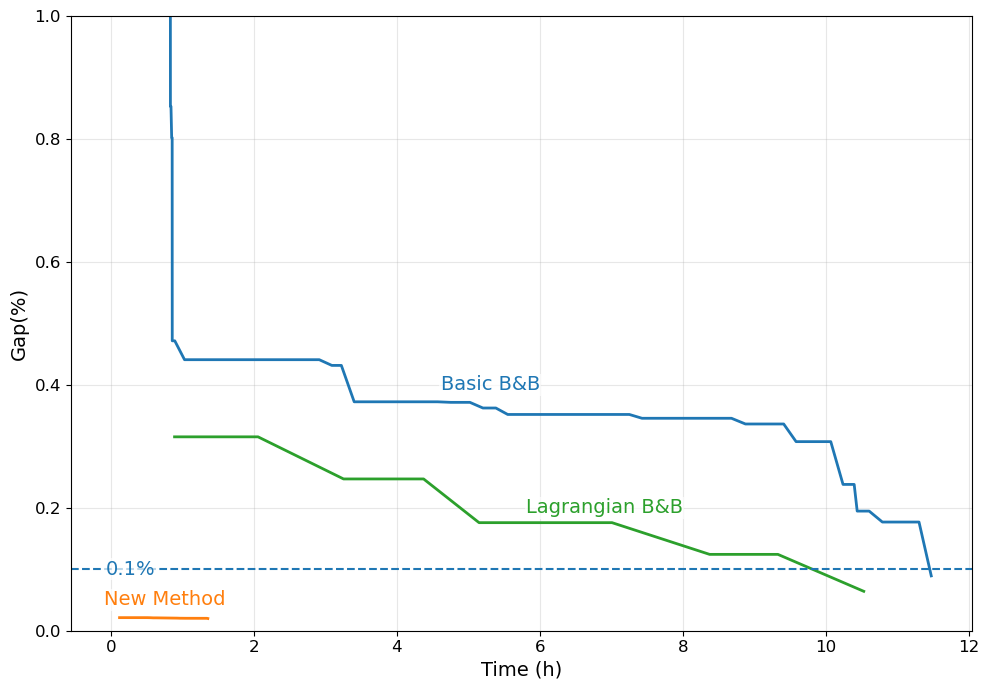

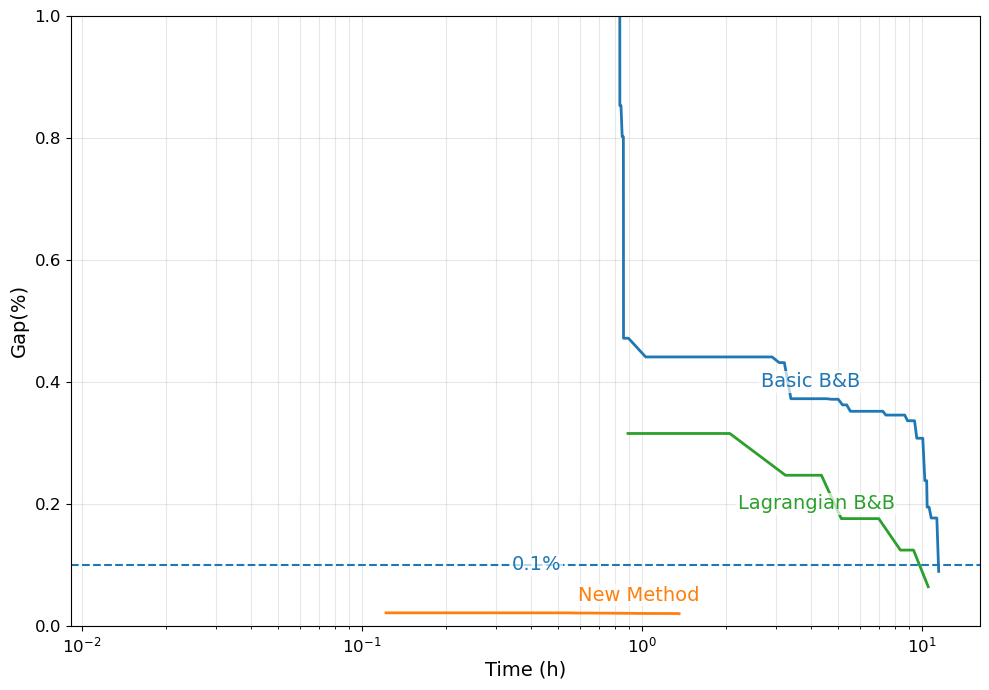

C:\Users\pc\AppData\Local\Temp\ipykernel_55560\3196004797.py:130: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(gymin, gymax)


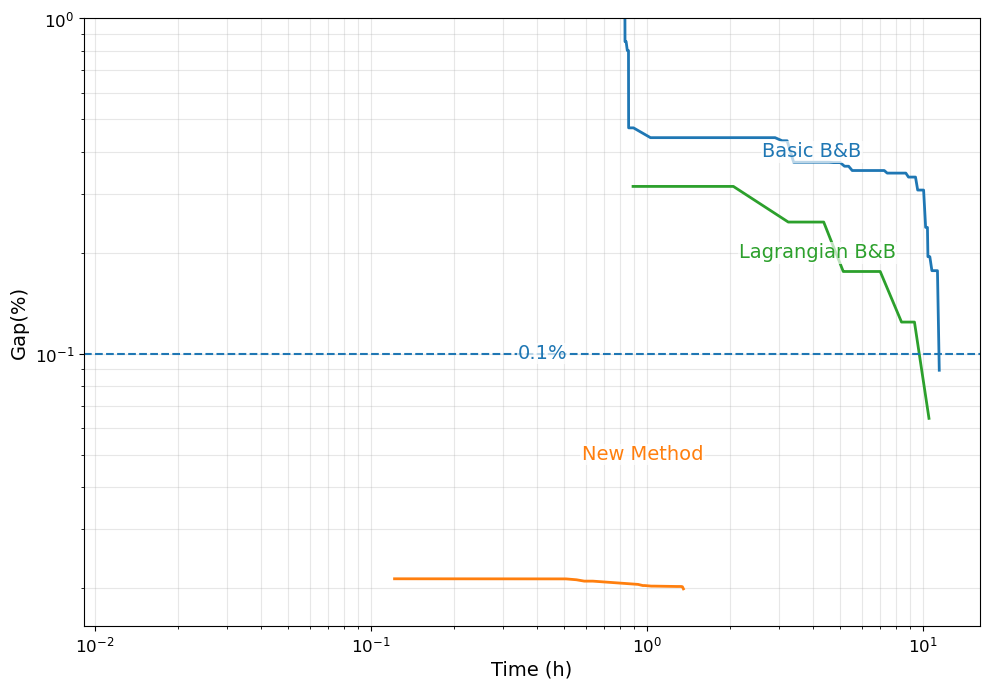

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


def _truncate_at_threshold(x, g, thresh):
    """Truncate curve at y=thresh by linear interpolation if it crosses from above to below.
    Keeps curves entirely below thresh unchanged.
    """
    if len(x) == 0:
        return x, g
    # If never goes below threshold, keep as-is
    if not (g.min() < thresh):
        return x, g
    # If entirely below threshold, keep as-is (e.g., New Method)
    if not (g.max() > thresh):
        return x, g
    # Find first index where g <= thresh
    idxs = (g <= thresh).to_numpy().nonzero()[0]
    if len(idxs) == 0:
        return x, g
    i = int(idxs[0])
    if i == 0:
        # starts below/at threshold
        return x.iloc[:1], g.iloc[:1]
    x1, y1 = float(x.iloc[i-1]), float(g.iloc[i-1])
    x2, y2 = float(x.iloc[i]), float(g.iloc[i])
    # If y1 already equals thresh, cut there
    if y1 == thresh:
        return x.iloc[:i], g.iloc[:i]
    # Linear interpolation to y=thresh (guard against flat)
    if y1 == y2:
        x_star = x2
    else:
        x_star = x1 + (x2 - x1) * (y1 - thresh) / (y1 - y2)
    x_new = pd.concat([x.iloc[:i], pd.Series([x_star])], ignore_index=True)
    g_new = pd.concat([g.iloc[:i], pd.Series([thresh])], ignore_index=True)
    return x_new, g_new

# Inputs
csv_snog = "snog_5f.csv"
csv_simp = "simp_1e3sc10_raw_post.csv"
csv_lg_k3 = "LG_K3_50cuts.csv"
csv_lg_k5 = "LG_K5_50cuts.csv"
csv_lg_k10 = "LG_K10_50cuts.csv"

# Y-axis range control for RelGap plots (set to None to disable)
gymin, gymax = 0, 1


# Font size controls
axis_label_size = 14
# (tick labels: numbers on axes)
tick_label_size = 12
MIPGAP_STR = "1e-3"  # for title

def _norm(c: str) -> str:
    return "".join(ch for ch in str(c).lower() if ch.isalnum())

def pick_column(df, want_keys):
    for c in df.columns:
        n = _norm(c)
        if any(k in n for k in want_keys):
            # for relgap we allow strings; numeric check only when applicable
            s = pd.to_numeric(df[c].astype(str).str.replace('%','', regex=False), errors="coerce")
            if s.notna().mean() > 0.5:
                return c
    raise ValueError(f"Can't find column for {want_keys}. Columns={list(df.columns)}")

def parse_relgap_percent(series: pd.Series) -> pd.Series:
    # Returns numeric percent (e.g., 0.021% -> 0.021)
    s = series.astype(str).str.strip()
    # keep inf as NaN for plotting
    s = s.str.replace('%', '', regex=False)
    s = s.replace({'inf':'', 'Inf':'', 'INF':'', 'nan':'', 'NaN':''})
    return pd.to_numeric(s, errors='coerce')

def load_one(fp: str, name: str):
    df = pd.read_csv(fp)
    time_col = pick_column(df, ["time", "times", "sec", "seconds"])
    rel_col  = pick_column(df, ["relgap", "rel gap", "relativegap", "relative gap"])
    return {"name": name, "df": df, "time_col": time_col, "rel_col": rel_col}

datasets = [
    load_one(csv_snog, "Basic B&B"),
    load_one(csv_simp, "New Method"),
    #load_one(csv_lg_k3, "LG K=3 "),
    #load_one(csv_lg_k5, "LG K=5 "),
    load_one(csv_lg_k10, "Lagrangian B&B"),
]

def plot_relgap(scale: str):
    """scale in {"linear","semilogx","loglog"}"""
    plt.figure(figsize=(10,7))

    name_to_color = {d["name"]: f"C{i}" for i, d in enumerate(datasets)}

    for d in datasets:
        df = d["df"]
        x = pd.to_numeric(df[d["time_col"]], errors="coerce")
        g = parse_relgap_percent(df[d["rel_col"]])

        mask = x.notna() & g.notna()
        x, g = x[mask], g[mask]

        x = x / 3600.0
        if scale in {"semilogx", "loglog"}:
            posx = x > 0
            x, g = x[posx], g[posx]
        if scale == "loglog":
            posy = g > 0
            x, g = x[posy], g[posy]

        color = name_to_color[d["name"]]

        if scale == "linear":
            plt.plot(x, g, linestyle="-", linewidth=2.0, color=color, label=d["name"])
        elif scale == "semilogx":
            plt.semilogx(x, g, linestyle="-", linewidth=2.0, color=color, label=d["name"])
        elif scale == "loglog":
            plt.loglog(x, g, linestyle="-", linewidth=2.0, color=color, label=d["name"])
        else:
            raise ValueError("scale must be one of: linear, semilogx, loglog")

    plt.xlabel("Time (h)", fontsize=axis_label_size)
    plt.ylabel("Gap(%)", fontsize=axis_label_size)
    plt.xticks(fontsize=tick_label_size)
    plt.yticks(fontsize=tick_label_size)

    if gymin is not None or gymax is not None:
        plt.ylim(gymin, gymax)

    plt.axhline(0.1, linestyle="--", linewidth=1.5, label="0.1%")
    # Inline labels (replace legend)
    ax = plt.gca()
    x0, x1 = ax.get_xlim()
    # Put labels slightly LEFT of the last x (prevents clipping at right boundary)
    dx_left = 0.03 * (x1 - x0) if (x1 > x0) else 0.0
    # Per-label manual offsets in DATA coordinates: label -> (dx, dy)
    #   dx: horizontal shift (same unit as x-axis: hours)
    #   dy: vertical shift (same unit as y-axis)
    # Example:
    # label_offsets = {
    #     'SNoGloDe  UB': (-0.2, 0.0),
    #     'Simplex  LB': (0.0, 0.001),
    # }
    label_offsets = {}
    # Absolute label positions in DATA coordinates: label -> (x, y)
    #   x: hours (same as x-axis)
    #   y: same unit as y-axis (e.g., Gap(%) on gap plots)
    # Example: place 'new method' at x=2h, y=0.5%
    # label_pos = { 'new method': (2.0, 0.5) }
    label_pos = {'Basic B&B': (6.0, 0.4),
                 'New Method': (1.6, 0.05) ,
                 'Lagrangian B&B': (8.0, 0.2)  
                }
    for ln in ax.get_lines():
        label = ln.get_label()
        if not label or label.startswith('_'):
            continue
        xd = ln.get_xdata(); yd = ln.get_ydata()
        if len(xd) == 0:
            continue
        j = None
        for k in range(len(xd)-1, -1, -1):
            try:
                xv = float(xd[k]); yv = float(yd[k])
            except Exception:
                continue
            if xv == xv and yv == yv:
                j = k
                break
        if j is None:
            continue
        if label in label_pos:
            xt, yt = label_pos[label]
        else:
            dx, dy = label_offsets.get(label, (0.0, 0.0))
            xt = float(xd[j]) - dx_left + dx
            yt = float(yd[j]) + dy
        ax.text(xt, yt, label, fontsize=14,
                color=ln.get_color(), va='center', ha='right', clip_on=False,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.0))
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_relgap("linear")
plot_relgap("semilogx")
plot_relgap("loglog")


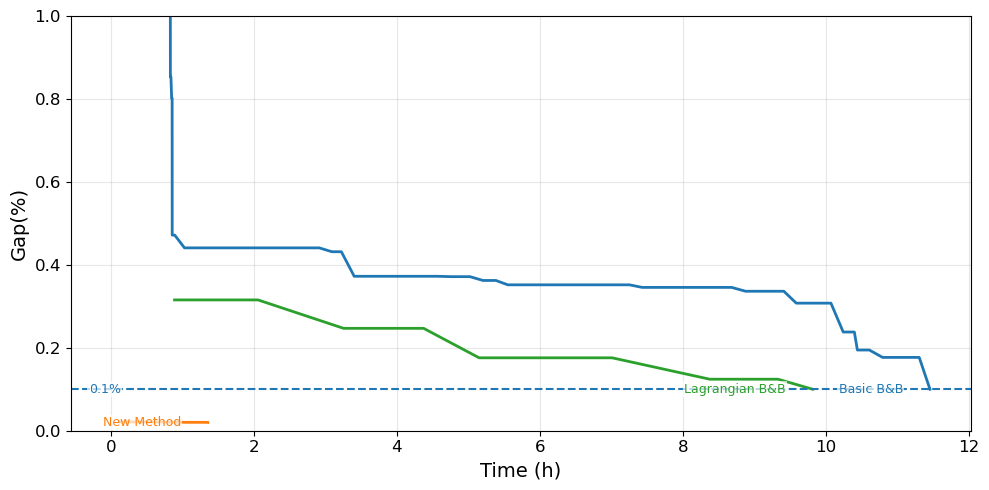

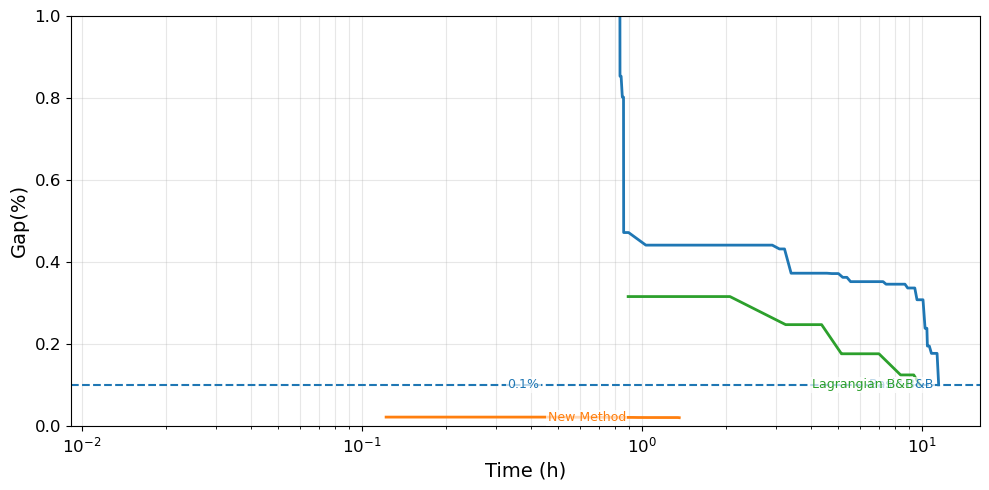

C:\Users\pc\AppData\Local\Temp\ipykernel_55560\3214781708.py:94: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(gymin, gymax)


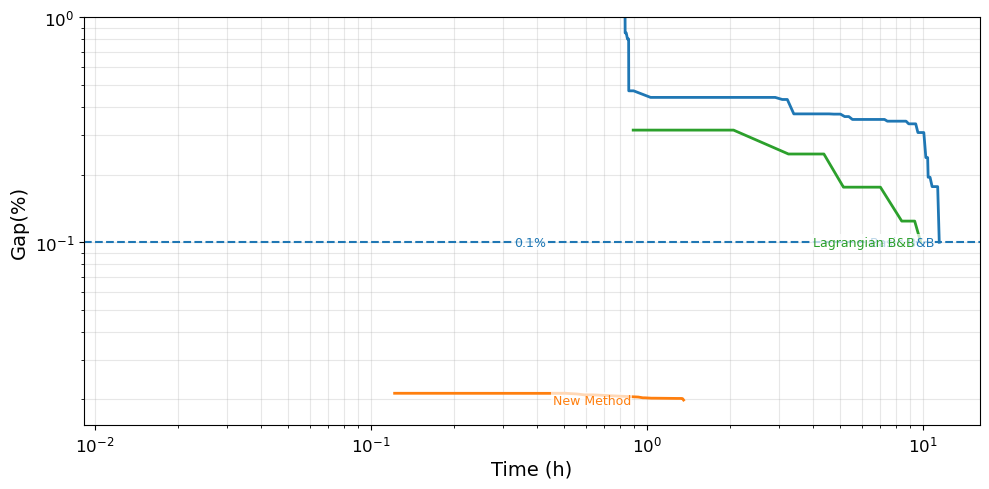

In [3]:
# ===== Threshold line and truncation (scheme 2) =====
GAP_THRESH = 0.1  # percent

def _truncate_at_threshold(x, g, thresh):
    """
    Scheme 2:
    If curve crosses from above -> at/below thresh, insert an interpolated point at y=thresh and truncate there.
    If never goes below thresh: keep as-is.
    If entirely below thresh (e.g., New Method): keep as-is.
    """
    if len(x) == 0:
        return x, g

    # If never goes below threshold, keep
    if not (g.min() < thresh):
        return x, g

    # If entirely below threshold, keep (do NOT extend upward)
    if not (g.max() > thresh):
        return x, g

    # Find first index where g <= thresh
    idxs = (g <= thresh).to_numpy().nonzero()[0]
    if len(idxs) == 0:
        return x, g
    i = int(idxs[0])

    if i == 0:
        # starts below/at threshold
        return x.iloc[:1], g.iloc[:1]

    x1, y1 = float(x.iloc[i-1]), float(g.iloc[i-1])
    x2, y2 = float(x.iloc[i]),   float(g.iloc[i])

    # If y1 already equals thresh, cut there
    if y1 == thresh:
        return x.iloc[:i], g.iloc[:i]

    # Linear interpolation to y=thresh (guard against flat)
    if y1 == y2:
        x_star = x2
    else:
        x_star = x1 + (x2 - x1) * (y1 - thresh) / (y1 - y2)

    x_new = pd.concat([x.iloc[:i], pd.Series([x_star])], ignore_index=True)
    g_new = pd.concat([g.iloc[:i], pd.Series([thresh])], ignore_index=True)
    return x_new, g_new


def plot_relgap(scale: str):
    """scale in {"linear","semilogx","loglog"}"""
    plt.figure(figsize=(10,5))

    name_to_color = {d["name"]: f"C{i}" for i, d in enumerate(datasets)}

    for d in datasets:
        df = d["df"]
        x = pd.to_numeric(df[d["time_col"]], errors="coerce")
        g = parse_relgap_percent(df[d["rel_col"]])

        mask = x.notna() & g.notna()
        x, g = x[mask], g[mask]

        # seconds -> hours (keep your existing behavior if already there; if not, this matches your current setup)
        x = x / 3600.0

        # Scheme 2: truncate at GAP_THRESH by interpolation when crossing
        x, g = _truncate_at_threshold(x, g, GAP_THRESH)

        if scale in {"semilogx", "loglog"}:
            posx = x > 0
            x, g = x[posx], g[posx]
        if scale == "loglog":
            posy = g > 0
            x, g = x[posy], g[posy]

        color = name_to_color[d["name"]]

        if scale == "linear":
            plt.plot(x, g, linestyle="-", linewidth=2.0, color=color, label=d["name"])
        elif scale == "semilogx":
            plt.semilogx(x, g, linestyle="-", linewidth=2.0, color=color, label=d["name"])
        elif scale == "loglog":
            plt.loglog(x, g, linestyle="-", linewidth=2.0, color=color, label=d["name"])
        else:
            raise ValueError("scale must be one of: linear, semilogx, loglog")

    plt.xlabel("Time (h)", fontsize=axis_label_size)
    plt.ylabel("Gap(%)", fontsize=axis_label_size)
    plt.xticks(fontsize=tick_label_size)
    plt.yticks(fontsize=tick_label_size)

    if gymin is not None or gymax is not None:
        plt.ylim(gymin, gymax)

    # Threshold line
    plt.axhline(GAP_THRESH, linestyle="--", linewidth=1.5, label="0.1%")

    # Inline labels (replace legend) — keep your absolute/offset system, plus special handling for 0.1%
    ax = plt.gca()
    x0, x1 = ax.get_xlim()
    dx_left = 0.03 * (x1 - x0) if (x1 > x0) else 0.0

    # Per-label manual offsets in DATA coordinates: label -> (dx, dy)
    label_offsets = {}

    # Absolute label positions in DATA coordinates: label -> (x, y)
    label_pos = {}
    # Put "0.1%" on the LEFT
    label_pos["0.1%"] = (x0 + 0.02 * (x1 - x0), GAP_THRESH)

    for ln in ax.get_lines():
        label = ln.get_label()
        if not label or label.startswith("_"):
            continue

        xd = ln.get_xdata()
        yd = ln.get_ydata()
        if len(xd) == 0:
            continue

        j = None
        for k in range(len(xd)-1, -1, -1):
            try:
                xv = float(xd[k]); yv = float(yd[k])
            except Exception:
                continue
            if xv == xv and yv == yv:
                j = k
                break
        if j is None:
            continue

        if label in label_pos:
            xt, yt = label_pos[label]
        else:
            dx, dy = label_offsets.get(label, (0.0, 0.0))
            xt = float(xd[j]) - dx_left + dx
            yt = float(yd[j]) + dy

        ha_for_label = "left" if label == "0.1%" else "right"
        ax.text(
            xt, yt, label, fontsize=9,
            color=ln.get_color(), va="center", ha=ha_for_label, clip_on=False,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.0)
        )

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_relgap("linear")
plot_relgap("semilogx")
plot_relgap("loglog")
